<a href="https://colab.research.google.com/github/JulmiBhaiPM/Monocular-distance-estimation/blob/main/PRP_Mark_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

BASE_PATH = "/content/drive/MyDrive/PRP_Project"

meta = pd.read_csv(f"{BASE_PATH}/metadata.csv")
ann  = pd.read_csv(f"{BASE_PATH}/annotations.csv")

Mounted at /content/drive


In [ ]:
#2
if 'image_name' in ann.columns:
    ann_clean = ann[['image_name', 'bbox_height']].rename(
        columns={'image_name':'filename','bbox_height':'pixel_height'}
    )
elif 'filename' in ann.columns:
    ann_clean = ann[['filename','bbox_height']].rename(
        columns={'bbox_height':'pixel_height'}
    )
else:
    raise ValueError("Cannot find filename column in annotations")

meta['filename'] = meta['filename'].astype(str)
ann_clean['filename'] = ann_clean['filename'].astype(str)

df = meta.merge(ann_clean, on='filename')
df['distance_m'] = df['distance_m'].astype(float)
df = df.sort_values('distance_m').reset_index(drop=True)

display(df[['distance_m','pixel_height']].head())
print("Total samples:", len(df))

,distance_m,pixel_height
0,1.0,2192
1,1.0,2246
2,1.0,2076
3,2.0,1282
4,2.0,1194


Total samples: 18


In [ ]:
#3
H = 1.05  # real object height in meters
f_mm = 5.23
sensor_width_mm = 6.4
image_width_px = 4624

f_px = (f_mm / sensor_width_mm) * image_width_px

k = f_px * H
b = 0

print("PHYSICAL CAMERA MODEL:")
print(f"pixel_height = {k:.2f} / distance")

PHYSICAL CAMERA MODEL:
pixel_height = 3967.61 / distance


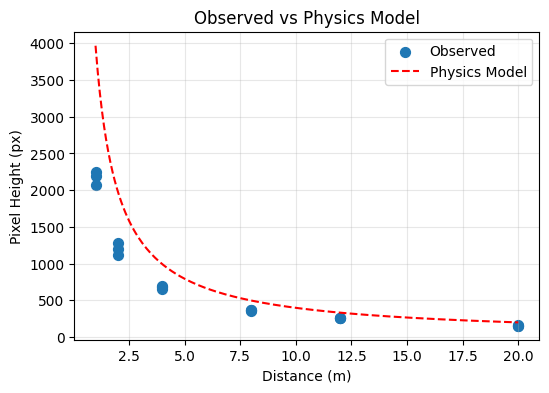

In [ ]:
#4
d_vals = np.linspace(1, 20, 200)
model_pixels = k / d_vals

plt.figure(figsize=(6,4))
plt.scatter(df['distance_m'], df['pixel_height'], label='Observed', s=50)
plt.plot(d_vals, model_pixels, 'r--', label='Physics Model')
plt.xlabel("Distance (m)")
plt.ylabel("Pixel Height (px)")
plt.title("Observed vs Physics Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#5

def predict_distance(pixel):
    return k / pixel

def distance_uncertainty(pixel, sigma_px):
    return abs(k / pixel**2) * sigma_px

In [ ]:
#6
test_pixels = [2200, 1800, 1200, 800, 400]

print("\nPIXEL → DISTANCE PREDICTIONS:\n")
for p in test_pixels:
    d = predict_distance(p)
    print(f"{p:>4} px → {d:.2f} m")


PIXEL → DISTANCE PREDICTIONS:

2200 px → 1.80 m
1800 px → 2.20 m
1200 px → 3.31 m
 800 px → 4.96 m
 400 px → 9.92 m



Prediction for 800px:
Distance = 4.96 ± 0.34 m


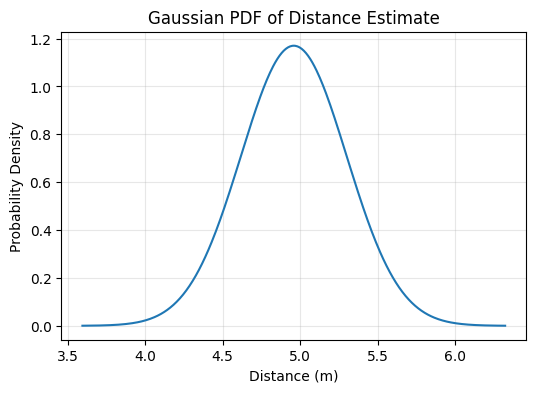

In [ ]:
#7

sigma_px = 55  # measured bounding-box pixel noise (from annotation variation)

p_test = 800
d_pred = predict_distance(p_test)
sigma_d = distance_uncertainty(p_test, sigma_px)

print(f"\nPrediction for {p_test}px:")
print(f"Distance = {d_pred:.2f} ± {sigma_d:.2f} m")

x_vals = np.linspace(d_pred-4*sigma_d, d_pred+4*sigma_d, 400)
pdf_vals = norm.pdf(x_vals, d_pred, sigma_d)

plt.figure(figsize=(6,4))
plt.plot(x_vals, pdf_vals)
plt.xlabel("Distance (m)")
plt.ylabel("Probability Density")
plt.title("Gaussian PDF of Distance Estimate")
plt.grid(alpha=0.3)
plt.show()